# Bridging ITK image data with NumPy array

This example illustrates interfacing ITK Image data with NumPy array.

In [1]:
import os
import numpy as np
from urllib.request import urlretrieve
import matplotlib.pyplot as plt
%matplotlib inline

import itk
from itkwidgets import view



In [2]:
input_image_path = "Slicer.png"

if not os.path.exists(input_image_path):
    url = "https://data.kitware.com/api/v1/file/602c10a22fa25629b97d2896/download"
    urlretrieve(url, input_image_path)

In [3]:
PixelType = itk.ctype("unsigned char")
ImageType = itk.Image[itk.UC, 2]

itk_image = itk.imread(input_image_path, PixelType)

OriginalRegion = itk_image.GetLargestPossibleRegion()
OriginalSize = OriginalRegion.GetSize()

print (f'ITK image size = {OriginalSize}')
view(itk_image, ui_collapsed=True)

ITK image size = itkSize2 ([221, 257])


Viewer(geometries=[], gradient_opacity=0.22, point_sets=[], rendered_image=<itk.itkImagePython.itkImageUC2; pr…

Array size = (257, 221)


(np.float64(-0.5), np.float64(220.5), np.float64(256.5), np.float64(-0.5))

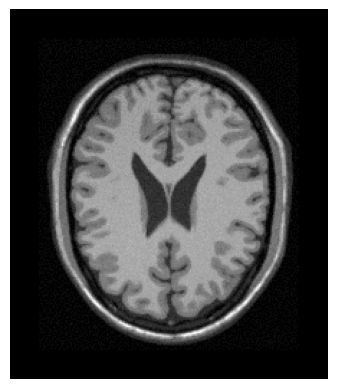

In [4]:
array = itk.GetArrayFromImage(itk_image, ttype=ImageType)
print(f'Array size = {array.shape}')
plt.gray()
plt.imshow(array)
plt.axis('off')

In [5]:
itk_image_convert = itk.GetImageFromArray(np.ascontiguousarray(array))
region = itk_image_convert.GetLargestPossibleRegion()
size = region.GetSize()
print(f'Size = {size}')

Size = itkSize2 ([221, 257])
